# ใบงานที่ 2: Data Preprocessing
### วิชา Machine Learning (04-624-201) — ภาควิชาวิศวกรรมคอมพิวเตอร์
**Dataset:** Thai Road Accident (2019–2022)

**ลิ้งค์อ้างอิง :** https://www.kaggle.com/datasets/thaweewatboy/thailand-road-accident-2019-2022?resource=download

ใบงาน: LAB1 (Dataset Exploration), LAB2 (Data Visualization), Part 3 (Data Cleaning), Part 4 (Feature Engineering)

---

ตรงนี้จะเป็นการ ดึงไลบรารีมาใช้ มีทั้ง pandas , numpy ,matplotlib.pyplot ,seaborn เป็นต้น

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

pd.set_option('display.max_columns', None)

---

ตรงนี้ผมเพิ่มเพราะ เจอปัญหา การเขียนคำที่เป็นภาษาไทย เลยทำการเพิ่ม font ภาษาไทย

In [111]:
import matplotlib.font_manager as fm
import urllib.request

url = "https://github.com/google/fonts/raw/main/ofl/notosansthai/NotoSansThai%5Bwdth%2Cwght%5D.ttf"
font_path = "NotoSansThai.ttf"
urllib.request.urlretrieve(url, font_path)

fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()

In [112]:
import matplotlib.pyplot as plt

# เพิ่มบรรทัดนี้ไว้ด้านบนสุดของสคริปต์พล็อตกราฟ
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Tahoma', 'Arial', 'Helvetica']

---

## LAB1: Dataset Exploration

ในขั้นตอนนี้เป็นการนำชุดข้อมูล (Dataset) ที่ดาวน์โหลดจาก Kaggle มาโหลดเข้าสู่โปรแกรมด้วยไลบรารี Pandas เพื่อเตรียมสำหรับการสำรวจและวิเคราะห์ข้อมูลในขั้นตอนถัดไป

In [113]:
import pandas as pd
df = pd.read_csv('thai_road_accident_2019_2022.csv')

### 1.2 Display Shape

ตรงนี้จะเป็นการ ตรวจสอบขนาดของชุดข้อมูล (Dataset Shape) เพื่อดูจำนวนแถว (Rows) และจำนวนคอลัมน์ (Columns) ซึ่งช่วยให้ทราบขนาดของข้อมูลก่อนเริ่มกระบวนการวิเคราะห์และทำ Data Preprocessing

In [114]:
print(f"จำนวนแถว (rows): {df.shape[0]:,}")
print(f"จำนวนคอลัมน์ (columns): {df.shape[1]}")

จำนวนแถว (rows): 81,735
จำนวนคอลัมน์ (columns): 18


มีชุดข้อมูลจำนวน 81,735 แถว และมี 18 คอลัมน์

---


### 1.3 Display Data Types

ส่วนตรงนี้จะเป็นการตรวจสอบชนิดข้อมูล (Data Types) ของแต่ละคอลัมน์

In [115]:
df.dtypes.to_frame(name='dtype')

,dtype
acc_code,int64
incident_datetime,str
report_datetime,str
province_th,str
province_en,str
agency,str
route,str
vehicle_type,str
presumed_cause,str
accident_type,str


ข้อมูลตัวเลข (int64) จำนวน 4 คอลัมน์ acc_code, number_of_vehicles_involved, number_of_fatalities ,number_of_injuries

ข้อมูลทศนิยม (float64) จำนวน 2 คอลัมน์  latitude, longitude

ข้อมูลข้อความ (str) จำนวน 12 คอลัมน์  province_th, vehicle_type, weather_condition, road_description เป็นต้น

---

### 1.4 Display Summary Statistics

ส่วนตรงนี้จะเป็นการแสดงสถิติเบื้องต้น (Summary Statistics) ของชุดข้อมูล เพื่อสรุปข้อมูลสำคัญของแต่ละคอลัมน์

In [116]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
acc_code,81735.0,NaN,NaN,NaN,4235766.317061,2128207.455614,571834.0,3789459.5,3824084.0,5831088.5,7571316.0
incident_datetime,81735,67917,2020-12-30 19:00:00,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
report_datetime,81735,66234,2022-12-29 11:39:00,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
province_th,81735,78,กรุงเทพมหานคร,6439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
province_en,81735,78,Bangkok,6439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
agency,81735,3,department of highways,75304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
route,81735,3882,ไม่ทราบ,2060,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_type,81735,15,4-wheel pickup truck,28445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
presumed_cause,81735,54,speeding,60373,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accident_type,81735,11,rollover/fallen on straight road,33046,NaN,NaN,NaN,NaN,NaN,NaN,NaN


จากการวิเคราะห์พบว่าชุดข้อมูลมีทั้งหมด 81,735 รายการ โดยจังหวัดที่เกิดอุบัติเหตุบ่อยที่สุดคือ กรุงเทพมหานคร จำนวนยานพาหนะที่เกี่ยวข้องเฉลี่ยประมาณ 1.53 คันต่อเหตุการณ์ จำนวนผู้เสียชีวิตเฉลี่ย 0.15 คน และจำนวนผู้บาดเจ็บเฉลี่ย 0.81 คน นอกจากนี้ สภาพอากาศที่พบมากที่สุดคือ clear (อากาศแจ่มใส) ซึ่งพบ 69,943 รายการ

---


### 1.5 Display Missing Values

ส่วนตรงนี้ก็จะเป็นการแสดงจำนวนและร้อยละของข้อมูลที่หายไปในแต่ละคอลัมน์

In [117]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct(%)': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary

,missing_count,missing_pct(%)
latitude,359,0.44
longitude,359,0.44


ส่วนของตรงนี้นะครับจะเป็นการสร้างกราฟแท่ง (Bar Chart) เพื่อแสดงจำนวนข้อมูลที่หายไป (Missing Values)

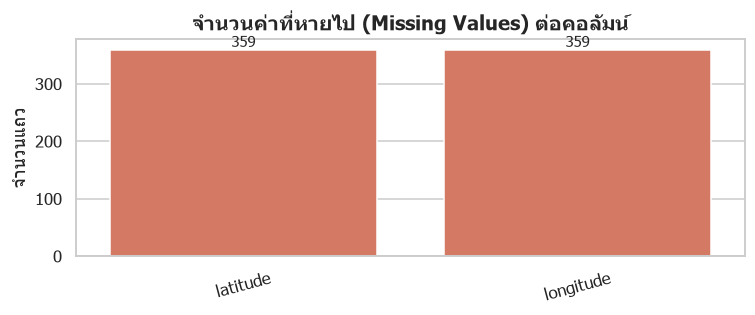

In [118]:
fig, ax = plt.subplots(figsize=(7, 3))
sns.barplot(x=missing_summary.index, y=missing_summary['missing_count'], ax=ax, color='#e76f51')
ax.set_title('จำนวนค่าที่หายไป (Missing Values) ต่อคอลัมน์', fontsize=13, fontweight='bold')
ax.set_ylabel('จำนวนแถว')
ax.set_xlabel('')
for i, v in enumerate(missing_summary['missing_count']):
    ax.text(i, v + 5, f'{v:,}', ha='center', fontsize=10)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

จากการตรวจสอบข้อมูลที่หายไป (Missing Values) พบว่ามีข้อมูลสูญหายเฉพาะคอลัมน์ latitude และ longitude จำนวน 359 รายการ คิดเป็นร้อยละ 0.44 ของข้อมูลทั้งหมด ซึ่งเป็นสัดส่วนที่ค่อนข้างน้อย จึงสามารถจัดการได้โดยการลบแถวที่มีข้อมูลหาย หรือใช้วิธีเติมข้อมูลตามความเหมาะสมในขั้นตอน Data Cleaning

---


### 1.6 Display Duplicate Records

ตรงนี้จะเป็นการตรวจสอบข้อมูลซ้ำทั้งในระดับแถวข้อมูลและรหัสอุบัติเหตุ (acc_code) เพื่อป้องกันข้อมูลซ้ำที่อาจส่งผลต่อการวิเคราะห์

In [119]:
dup_count = df.duplicated().sum()
dup_id_count = df['acc_code'].duplicated().sum()
print(f"จำนวนแถวที่ซ้ำกันทั้งหมด (all columns): {dup_count}")
print(f"จำนวน acc_code ที่ซ้ำกัน: {dup_id_count}")

จำนวนแถวที่ซ้ำกันทั้งหมด (all columns): 0
จำนวน acc_code ที่ซ้ำกัน: 0


ผลการตรวจสอบพบว่าไม่พบข้อมูลซ้ำทั้งในระดับแถวข้อมูลและรหัสอุบัติเหตุ (acc_code) ดังนั้นจึงไม่จำเป็นต้องลบข้อมูลซ้ำออกจากชุดข้อมูล

---


### 1.7 Display Class Distribution

ส่วนตรงนี้จะเป็นการจัดกลุ่มความรุนแรงของอุบัติเหตุ (Severity Class)ครับ

In [120]:
def classify_severity(row):
    if row['number_of_fatalities'] > 0:
        return 'Fatal'
    elif row['number_of_injuries'] > 0:
        return 'Injury'
    else:
        return 'Property Damage Only'

df['severity'] = df.apply(classify_severity, axis=1)
class_dist = df['severity'].value_counts()
class_dist

severity
Injury                  36325
Property Damage Only    35275
Fatal                   10135
Name: count, dtype: int64

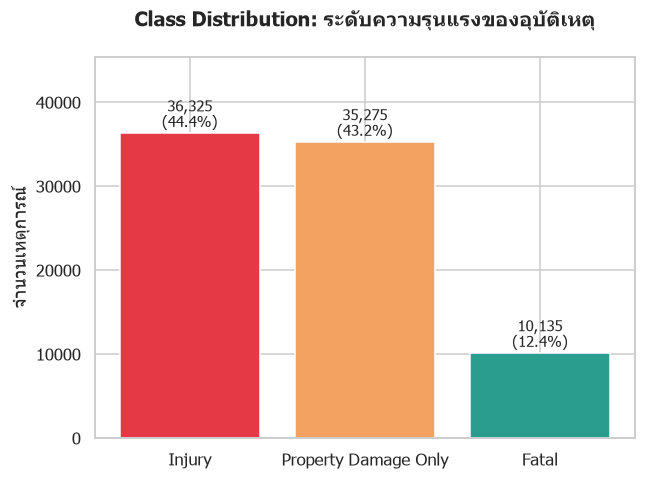

In [121]:
fig, ax = plt.subplots(figsize=(6, 4.5))
colors = ['#e63946', '#f4a261', '#2a9d8f']
bars = ax.bar(class_dist.index, class_dist.values, color=colors)
ax.set_title('Class Distribution: ระดับความรุนแรงของอุบัติเหตุ', fontsize=13, fontweight='bold', pad=20)
ax.set_ylabel('จำนวนเหตุการณ์')
ax.set_ylim(0, class_dist.max() * 1.25)   # เผื่อพื้นที่ด้านบนไม่ให้ตัวเลขชนหัวเรื่อง
for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h + class_dist.max()*0.02, f'{h:,}\n({h/len(df)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

จากการจำแนกระดับความรุนแรงของอุบัติเหตุ (Severity)

พบว่าอุบัติเหตุส่วนใหญ่เป็นกลุ่ม Injury (มีผู้บาดเจ็บ) จำนวน 36,325 เคส

Property Damage Only (เสียหายเฉพาะทรัพย์สิน) จำนวน 35,275 เคส

และกลุ่ม Fatal (ถึงแก่ชีวิต) ซึ่งมีผู้เสียชีวิต จำนวน 10,135 เคส

ซึ่งสะท้อนให้เห็นว่าแม้เคสส่วนใหญ่จะไม่ได้นำไปสู่การเสียชีวิต แต่เกือบครึ่งหนึ่งของอุบัติเหตุทั้งหมดส่งผลให้เกิดการบาดเจ็บทางร่างกายของผู้ประสบเหตุ

---
---

## LAB2: Data Visualization

### 2.1 Histogram

โค้ดนี้คือการนำข้อมูลอุบัติเหตุมาพล็อตเพื่อดู "ความถี่" ของเหตุการณ์ โดยแบ่งออกเป็น 3 กราฟย่อยเรียงต่อกันในแนวนอนครับ

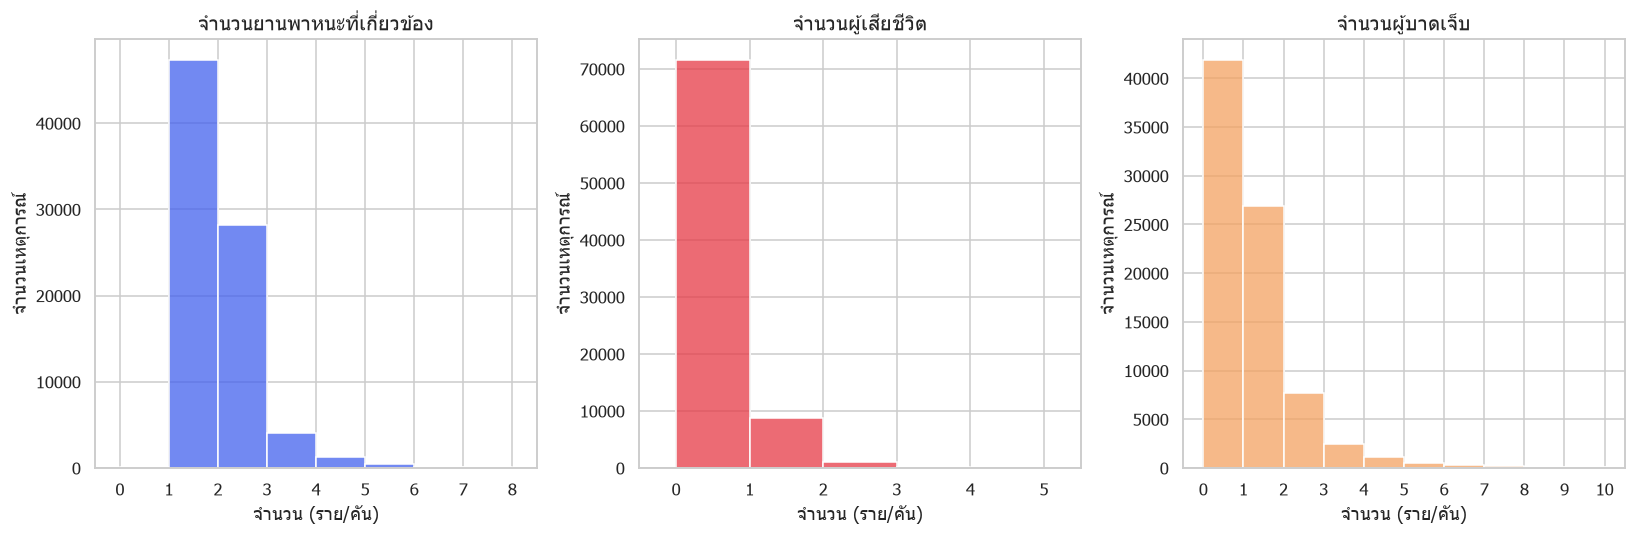

In [122]:
num_cols = ['number_of_vehicles_involved', 'number_of_fatalities', 'number_of_injuries']
fig, axes = plt.subplots(1, 3, figsize=(15, 5)) # ปรับความสูงเพิ่มนิดนึงให้โปร่งขึ้น
titles = ['จำนวนยานพาหนะที่เกี่ยวข้อง', 'จำนวนผู้เสียชีวิต', 'จำนวนผู้บาดเจ็บ']
colors = ['#4361ee', '#e63946', '#f4a261']

max_limits = [8, 5, 10] 

for ax, col, title, c, max_lim in zip(axes, num_cols, titles, colors, max_limits):

    sns.histplot(df[col], bins=range(0, max_lim + 2), ax=ax, color=c, edgecolor='white')
    
    ax.set_xlim(-0.5, max_lim + 0.5)
    
    ax.set_xticks(range(0, max_lim + 1))
    
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('จำนวน (ราย/คัน)')
    ax.set_ylabel('จำนวนเหตุการณ์')

plt.tight_layout()
plt.show()

**ผลจากกราฟ 3 ช่องแรก (การกระจายเชิงจำนวน)**

จำนวนยานพาหนะที่เกี่ยวข้อง : เคสส่วนใหญ่จะอยู่ที่ 2 คัน

จำนวนผู้เสียชีวิต : อุบัติเหตุ เกือบทั้งหมดมีผู้เสียชีวิตเป็น 0 

จำนวนผู้บาดเจ็บ : ส่วนใหญ่มีผู้บาดเจ็บอยู่ที่ 0-2 คนต่อครั้ง

---


โค้ดส่วนนี้เป็นการนำข้อมูล "เวลาที่เกิดอุบัติเหตุ" มาวิเคราะห์เพื่อดูว่า ในช่วงเวลาไหนของวันที่เกิดอุบัติเหตุบ่อยที่สุด ครับ

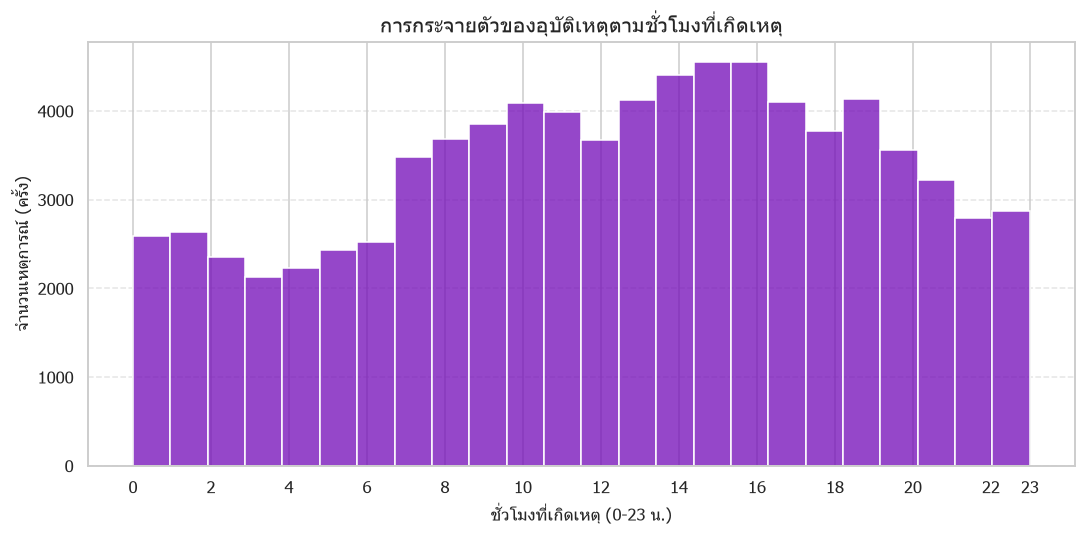

In [123]:
df['incident_datetime'] = pd.to_datetime(df['incident_datetime'])
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df['incident_datetime'].dt.hour, bins=24, ax=ax, color='#7209b7', edgecolor='white')

ax.set_title('การกระจายตัวของอุบัติเหตุตามชั่วโมงที่เกิดเหตุ', fontsize=14)

xticks_hours = list(range(0, 24, 2))
if 23 not in xticks_hours:
    xticks_hours.append(23)
ax.set_xticks(xticks_hours)

ax.set_xlabel('ชั่วโมงที่เกิดเหตุ (0-23 น.)', fontsize=11)
ax.set_ylabel('จำนวนเหตุการณ์ (ครั้ง)', fontsize=11)

# เปิดเส้นตารางแนวนอนจางๆ ให้ดูง่าย
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**ปัจจัยด้านเวลาที่ส่งผลต่อการเกิดเหตุ (กราฟสีม่วง)**

ช่วงพีค คือ ช่วงบ่าย: อุบัติเหตุไม่ได้พุ่งเฉพาะช่วงเช้าเข้างาน แต่จะเริ่มสะสมและหนาแน่นที่สุดในช่วงเวลา 13:00 - 17:00 น. (พีคสุดคือ บ่าย 3 ถึง 4 โมงเย็น)

ช่วงปลอดภัย คือ เช้ามืด: ช่วงเวลาที่มีอุบัติเหตุน้อยที่สุดในรอบวันคือ 02:00 - 05:00 น. เนื่องจากบนถนนมีรถขับสัญจรน้อยครับ

---

### 2.2 Correlation Heatmap

ส่วนตรงนี้จะเป็น โค้ดการสร้าง "Correlation Heatmap"เพื่อดูว่าตัวแปรที่เป็นตัวเลขในชุดข้อมูลนี้ มีความสัมพันธ์หรือส่งผลกระทบต่อกันมากน้อยแค่ไหน ครับ

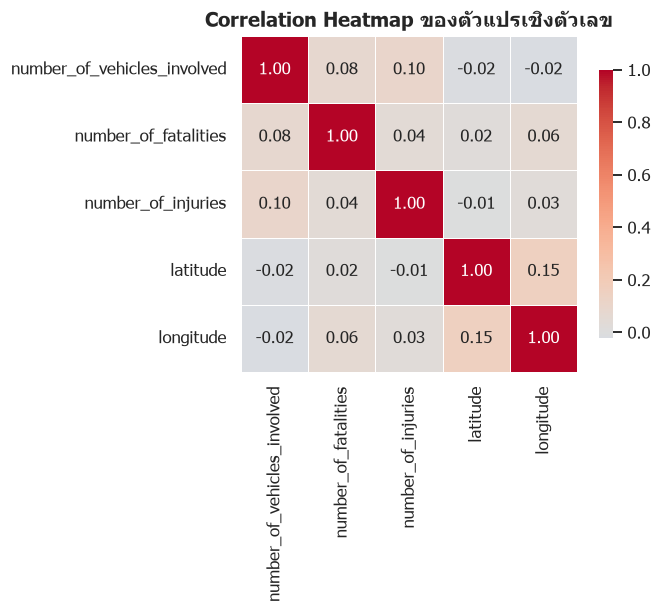

In [124]:
corr_cols = ['number_of_vehicles_involved', 'number_of_fatalities', 'number_of_injuries', 'latitude', 'longitude']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': .8}, ax=ax)
ax.set_title('Correlation Heatmap ของตัวแปรเชิงตัวเลข', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

heatmap นี้แสดงว่าตัวแปรเชิงตัวเลขทั้ง 5 ตัว (จำนวนรถ, จำนวนผู้เสียชีวิต, จำนวนผู้บาดเจ็บ, latitude, longitude) 

ไม่มีความสัมพันธ์เชิงเส้นต่อกันเลย ค่าทั้งหมดอยู่ในช่วง -0.02 ถึง 0.15 

ค่าที่สูงสุดคือ latitude-longitude (0.15) 

---
---

## Part 3: Data Cleaning

### 3.1 Missing Value Handling

โค้ดส่วนนี้คือการทำ Data Cleaning เพื่อจัดการกับข้อมูลพิกัด (Latitude และ Longitude) ที่มันสูญหายหรือเป็นช่องว่าง (Missing Values) ครับ

In [ ]:
print("ก่อนแก้ไข - missing lat/lon:", df['latitude'].isna().sum(), df['longitude'].isna().sum())

df['latitude'] = df.groupby('province_en')['latitude'].transform(lambda x: x.fillna(x.median()))
df['longitude'] = df.groupby('province_en')['longitude'].transform(lambda x: x.fillna(x.median()))

# เหลือกรณีจังหวัดที่ทั้งกลุ่มไม่มีพิกัดเลย ใช้ median รวมทั้งประเทศแทน
df['latitude'] = df['latitude'].fillna(df['latitude'].median())
df['longitude'] = df['longitude'].fillna(df['longitude'].median())

print("หลังแก้ไข - missing lat/lon:", df['latitude'].isna().sum(), df['longitude'].isna().sum())

ก่อนแก้ไข - missing lat/lon: 359 359
หลังแก้ไข - missing lat/lon: 0 0


ก่อนแก้ไข: เราพบว่ามีข้อมูลอุบัติเหตุอยู่ 359 เคส ที่ข้อมูลพิกัดขาดหายไป (เป็นค่าว่างหรือ Missing Values) 

หลังแก้ไข: หลังจากที่ใช้เทคนิคเติมค่ากลาง (Median) แยกตามกลุ่มจังหวัดแล้ว ทำให้เห็นว่าค่าว่างได้ลดลงเหลือ 0 เคส ทันทีครับ

---


### 3.2 Duplicate Removal

เป็นขั้นตอนการเคลียร์ข้อมูลที่ซ้ำซ้อน (Duplicate Removal) ครับ เพื่อป้องกันไม่ให้ข้อมูลอุบัติเหตุเคสเดิมถูกนับอีกรอบ

In [126]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"จำนวนแถวก่อนลบซ้ำ: {before:,} | หลังลบซ้ำ: {after:,} | ลบไป: {before-after} แถว")

จำนวนแถวก่อนลบซ้ำ: 81,735 | หลังลบซ้ำ: 81,735 | ลบไป: 0 แถว


ผลลัพธ์ที่ได้คือ จำนวนแถวก่อนและหลังลบซ้ำเท่ากันที่ 81,735 แถว สรุปคือลบไป 0 แถวครับ

แสดงว่าไม่มีข้อมูลที่ซ้ำกันเลย



---
---

## Part 4: Feature Engineering

### 4.1 Label Encoding

เป็นขั้นตอนการแปลงข้อมูลหมวดหมู่ให้เป็นตัวเลข หรือขั้นตอน Encoding ครับ

In [130]:
from sklearn.preprocessing import LabelEncoder

severity_order = {'Property Damage Only': 0, 'Injury': 1, 'Fatal': 2}
df['severity_encoded'] = df['severity'].map(severity_order)

df[['severity', 'severity_encoded']].drop_duplicates().sort_values('severity_encoded')

,severity,severity_encoded
4,Property Damage Only,0
0,Injury,1
2,Fatal,2


ตารางที่แสดงออกมา คือ "ตารางสรุปผลการจับคู่ (Mapping)" เพื่อรีเช็กความถูกต้อง ครับ

Property Damage Only (เสียหายแค่ทรัพย์สิน) แปลงเป็นเลข 0

Injury (บาดเจ็บ) แปลงเป็นเลข 1

Fatal (เสียชีวิต) แปลงเป็นเลข 2


---

### 4.2 One-Hot Encoding

ถัดมาเป็นขั้นตอนการแปลงข้อมูลหมวดหมู่ด้วยวิธี One-Hot Encoding กับคอลัมน์สภาพอากาศ (weather_condition) ครับ

In [131]:
weather_ohe = pd.get_dummies(df['weather_condition'], prefix='weather')
df_encoded = pd.concat([df, weather_ohe], axis=1)

print("คอลัมน์ที่ได้จาก One-Hot Encoding:")
print(list(weather_ohe.columns))
df_encoded[['weather_condition'] + list(weather_ohe.columns)].head()

คอลัมน์ที่ได้จาก One-Hot Encoding:
['weather_clear', 'weather_dark', 'weather_foggy', 'weather_land slide', 'weather_natural disaster', 'weather_other', 'weather_rainy']


,weather_condition,weather_clear,weather_dark,weather_foggy,weather_land slide,weather_natural disaster,weather_other,weather_rainy
0,clear,True,False,False,False,False,False,False
1,clear,True,False,False,False,False,False,False
2,clear,True,False,False,False,False,False,False
3,clear,True,False,False,False,False,False,False
4,clear,True,False,False,False,False,False,False


ผลลัพธ์ที่ได้หลังจากทำ One-Hot Encoding คอลัมน์สภาพอากาศครับ
คอลัมน์ใหม่ที่เพิ่มขึ้นมา : ระบบได้แยกสภาพอากาศออกเป็น 7 คอลัมน์ย่อย

ได้แก่ clear (แจ่มใส), dark (มืด/ไม่มีแสง), foggy (หมอกลง), land slide (ดินสไลด์), natural disaster (ภัยธรรมชาติ), other (อื่น ๆ) และ rainy (ฝนตก) ครับ

จากตัวอย่าง 5 แถวแรกจะเห็นว่าเหตุการณ์ทั้งหมดเกิดขึ้นตอนสภาพอากาศแจ่มใส คอลัมน์ [weather_clear] จึงขึ้นสถานะเป็น True (1)

---
---

## สรุป
- **LAB1**: สำรวจ dataset ขนาด ~81,700 แถว, 18 คอลัมน์ พบ missing values ในพิกัด (lat/lon) และไม่มี duplicate records
- **LAB2**: histogram แสดงว่าอุบัติเหตุส่วนใหญ่เกี่ยวข้องกับยานพาหนะ 1-2 คัน และ correlation heatmap แสดงความสัมพันธ์ระหว่างตัวแปรตัวเลข
- **Part 3**: เติมค่า missing และแก้ไขพิกัดผิดปกติด้วย median รายจังหวัด, แปลงชนิดข้อมูล datetime และ category
- **Part 4**: ใช้ Label Encoding กับตัวแปรที่มีลำดับ (severity) และ One-Hot Encoding กับตัวแปรไม่มีลำดับ (weather_condition)

## จัดทำโดย

นายถิรวัฒน์ แสงกลิ่น รหัสนักศึกษา 116710400231-2 กลุ่มที่ 2